# Gradient Boosting: XGBoost, LightGBM y CatBoost

Ya conocemos **bagging** (Random Forest): varios árboles en **paralelo**, cada uno entrenado sobre una submuestra aleatoria. El promedio reduce varianza.

**Boosting** es diferente: los árboles se entrenan en **secuencia**. Cada árbol corrige los errores del anterior.

$$\hat{y} = \sum_{k=1}^{N} \eta \cdot b_k(x)$$

donde $b_k$ aprende a predecir el **residuo** del paso anterior y $\eta$ es el learning rate.

| | Bagging (Random Forest) | Boosting |
|---|---|---|
| Entrenamiento | Paralelo | **Secuencial** |
| Cada árbol aprende | Una submuestra de $y$ | El **residuo** del anterior |
| Combinación | Promedio | Suma ponderada |
| Reduce | Varianza | **Sesgo** |

In [2]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target  # precio en 100k USD

print(df.shape)
print(df.head())

X = df.drop("Price", axis=1).values
y = df["Price"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(np.mean(y))

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Train: (16512, 8)  |  Test: (4128, 8)
2.0685581690891475


In [13]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Baseline: 

In [9]:
promedio_precio = y_train.mean()

y_pred_baseline = [promedio_precio] * len(y_test)

rmse_baseline = mean_squared_error(y_test, y_pred_baseline) ** 0.5
print(f"RMSE Baseline: {rmse_baseline:.4f}")

print(f"Precio promedio:        {promedio_precio:.4f}  (${rmse_baseline:.4f}k)")
print(rmse_baseline/promedio_precio)

RMSE Baseline: 1.1449
Precio promedio:        2.0719  ($1.1449k)
0.5525510010204624


## Random Forest

Un solo árbol es nuestro punto de comparación. Vamos a ver cuánto mejora el boosting.

In [27]:
# Entrenamos un modelo de random forest y veamos el rmse en el set de test


model_tree = DecisionTreeRegressor(random_state=42,max_depth=10)

model_tree.fit(X_train_scaled, y_train)

y_pred_tree = model_tree.predict(X_test_scaled)
rmse_tree = mean_squared_error(y_test, y_pred_tree) ** 0.5
print(f"RMSE Árbol de decisión: {rmse_tree:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_tree*100:.0f}k  ({rmse_tree/y.mean()*100:.1f}% del precio medio)")

model_tree = DecisionTreeRegressor(random_state=42,max_depth=10)

model_tree.fit(X_train, y_train)

y_pred_tree = model_tree.predict(X_test)
rmse_tree = mean_squared_error(y_test, y_pred_tree) ** 0.5

print(f"RMSE Árbol de decisión: {rmse_tree:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_tree*100:.0f}k  ({rmse_tree/y.mean()*100:.1f}% del precio medio)")

RMSE Árbol de decisión: 0.6440
Precio promedio:        2.0686  ($207k)
Error promedio:         $64k  (31.1% del precio medio)
RMSE Árbol de decisión: 0.6446
Precio promedio:        2.0686  ($207k)
Error promedio:         $64k  (31.2% del precio medio)


In [14]:
# Entrenamos un modelo de random forest y veamos el rmse en el set de test

# StandarScaler --> estandarización
# MinMaxScaler --> normalización
# RobustScaler --> robustez a outliers

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model_rf = RandomForestRegressor(random_state=42,max_depth=10)
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(X_test_scaled)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print(f"RMSE Random Forest: {rmse_rf:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_rf*100:.0f}k  ({rmse_rf/y.mean()*100:.1f}% del precio medio)")


model_rf = RandomForestRegressor(random_state=42,max_depth=10)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print(f"RMSE Random Forest: {rmse_rf:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_rf*100:.0f}k  ({rmse_rf/y.mean()*100:.1f}% del precio medio)")

RMSE Random Forest: 0.5444
Precio promedio:        2.0686  ($207k)
Error promedio:         $54k  (26.3% del precio medio)
RMSE Random Forest: 0.5445
Precio promedio:        2.0686  ($207k)
Error promedio:         $54k  (26.3% del precio medio)


## XGBoost

**eXtreme Gradient Boosting** — la librería que popularizó el boosting en competencias de ML (Kaggle).

**Claves:**
- Añade regularización L1/L2 sobre los pesos de los nodos
- Usa segunda derivada (hessiano) para actualizaciones más precisas
- API idéntica a scikit-learn: `fit` / `predict`

```
pip install xgboost
```

In [28]:
import xgboost as xgb

model_xgb = xgb.XGBRegressor(random_state=42, max_depth=10,verbose=1)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5

print(f"RMSE XGBoost: {rmse_xgb:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_xgb*100:.0f}k  ({rmse_xgb/y.mean()*100:.1f}% del precio medio)")

c:\Users\57304\anaconda3\envs\mi_entorno\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:09:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RMSE XGBoost: 0.4864
Precio promedio:        2.0686  ($207k)
Error promedio:         $49k  (23.5% del precio medio)


## LightGBM

**Light Gradient Boosting Machine** — desarrollado por Microsoft (2017).

**Diferencia clave frente a XGBoost:**  
Crece el árbol **hoja a hoja** (*leaf-wise*) en lugar de nivel a nivel. Esto lo hace significativamente más rápido en datasets grandes.

- Maneja variables categóricas directamente (sin encoding manual)
- Ideal cuando tienes millones de filas

```
pip install lightgbm
```

In [25]:
import lightgbm as lgb

model_lgb = lgb.LGBMRegressor(random_state=42, max_depth=10, verbose = -1)
model_lgb.fit(X_train, y_train)
y_pred_lgb = model_lgb.predict(X_test)
rmse_lgb = mean_squared_error(y_test, y_pred_lgb) ** 0.5

print(f"RMSE LightGBM: {rmse_lgb:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_lgb*100:.0f}k  ({rmse_lgb/y.mean()*100:.1f}% del precio medio)")

RMSE LightGBM: 0.4630
Precio promedio:        2.0686  ($207k)
Error promedio:         $46k  (22.4% del precio medio)


c:\Users\57304\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## CatBoost

**Categorical Boosting** — desarrollado por Yandex (2017).

**Diferencia clave:**  
Codifica variables categóricas de forma **ordenada** internamente, evitando *target leakage* (filtración de información del futuro al pasado durante el entrenamiento).

- Defaults muy sólidos: suele funcionar bien sin afinar hiperparámetros
- Excelente cuando tienes muchas variables categóricas

```
pip install catboost
```

In [29]:
from catboost import CatBoostRegressor

#entrenamos un modelo de catboost y veamos el rmse en el set de test
model_cat = CatBoostRegressor(random_state=42, max_depth=10, verbose = 1)
model_cat.fit(X_train, y_train)
y_pred_cat = model_cat.predict(X_test)
rmse_cat = mean_squared_error(y_test, y_pred_cat) ** 0.5


print(f"RMSE CatBoost: {rmse_cat:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_cat*100:.0f}k  ({rmse_cat/y.mean()*100:.1f}% del precio medio)")

Learning rate set to 0.063766
0:	learn: 1.1109688	total: 857ms	remaining: 14m 16s
1:	learn: 1.0696842	total: 1.14s	remaining: 9m 26s
2:	learn: 1.0315964	total: 1.33s	remaining: 7m 23s
3:	learn: 0.9930232	total: 1.64s	remaining: 6m 48s
4:	learn: 0.9610312	total: 1.97s	remaining: 6m 32s
5:	learn: 0.9276667	total: 2.3s	remaining: 6m 21s
6:	learn: 0.8984092	total: 2.56s	remaining: 6m 3s
7:	learn: 0.8702230	total: 2.83s	remaining: 5m 51s
8:	learn: 0.8451443	total: 3.08s	remaining: 5m 39s
9:	learn: 0.8200168	total: 3.28s	remaining: 5m 24s
10:	learn: 0.7976711	total: 3.48s	remaining: 5m 13s
11:	learn: 0.7771210	total: 3.7s	remaining: 5m 4s
12:	learn: 0.7567224	total: 3.99s	remaining: 5m 3s
13:	learn: 0.7390897	total: 4.32s	remaining: 5m 4s
14:	learn: 0.7237869	total: 4.59s	remaining: 5m 1s
15:	learn: 0.7100973	total: 4.78s	remaining: 4m 53s
16:	learn: 0.6970781	total: 5.02s	remaining: 4m 50s
17:	learn: 0.6853381	total: 5.19s	remaining: 4m 43s
18:	learn: 0.6735066	total: 5.49s	remaining: 4m 43

## Comparación final

Los cuatro modelos con los mismos hiperparámetros base. El árbol único es nuestro baseline.

Modelo                    RMSE test
------------------------------------
Árbol de decisión          0.645
Random Forest              0.545
Random Forest (baseline)   0.414
XGBoost                    0.486
LightGBM                   0.449
CatBoost                   0.435
CatBoost
(train)           0.212


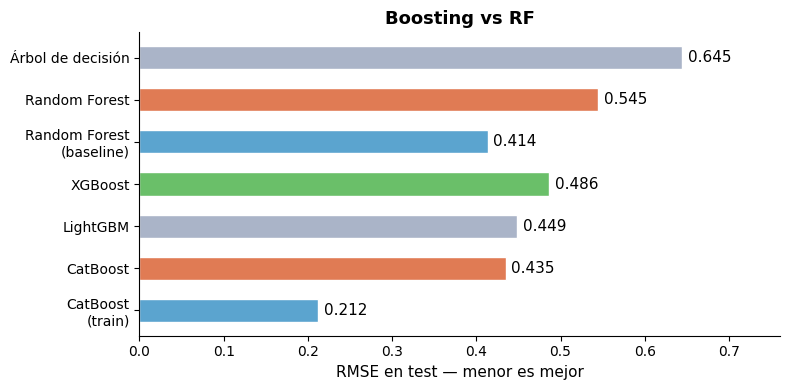

In [44]:
y_pred_train_cat = model_cat.predict(X_train)
rmse_train_cat = mean_squared_error(y_train, y_pred_train_cat) ** 0.5

y_pred_train_rf = model_rf.predict(X_train)
rmse_train_rf = mean_squared_error(y_train, y_pred_train_rf) ** 0.5

resultados = {
    #"Baseline (promedio)": rmse_baseline,
    "Árbol de decisión": rmse_tree,
    "Random Forest": rmse_rf,
    "Random Forest\n(baseline)": rmse_train_rf,
    "XGBoost": rmse_xgb,
    "LightGBM": rmse_lgb,
    "CatBoost": rmse_cat,
    "CatBoost\n(train)": rmse_train_cat
}

print("Modelo                    RMSE test")
print("-" * 36)
for modelo, rmse in resultados.items():
    nombre_limpio = modelo.replace("\n(baseline)", " (baseline)")
    print(f"{nombre_limpio:<26} {rmse:.3f}")

# Gráfico
colores = ["#aab4c8", "#e07b54", "#5ba4cf", "#6abf69"]

fig, ax = plt.subplots(figsize=(8, 4))
modelos = list(resultados.keys())
mses = list(resultados.values())

bars = ax.barh(modelos, mses, color=colores, edgecolor="white", height=0.55)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=11)
ax.set_xlabel("RMSE en test — menor es mejor", fontsize=11)
ax.set_title("Boosting vs RF", fontsize=13, fontweight="bold")
ax.set_xlim(0, max(mses) * 1.18)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [38]:
# mejorar el catboost regressor
from sklearn.model_selection import GridSearchCV

grid = {    
    "n_estimators": [100, 200],
    "max_depth": [6, 10],
        "learning_rate": [0.01, 0.1],
    "reg_lambda": [1, 10],
}

grid_search = GridSearchCV(estimator=model_lgb, param_grid=grid, cv=3, scoring="neg_mean_squared_error", verbose=1)
grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\Users\57304\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\57304\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\57304\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\57304\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\57304\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fit

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMRegressor...2, verbose=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [6, 10], 'n_estimators': [100, 200], 'reg_lambda': [1, 10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [ ]:
print(grid_search.best_params_)

import lightgbm as lgb

model_lgb = lgb.LGBMRegressor(learning_rate=0.1, max_depth=10,n_estimators=200,reg_lambda=100, random_state=42, verbose = -1)
model_lgb.fit(X_train, y_train)
y_pred_lgb = model_lgb.predict(X_test)
rmse_lgb = mean_squared_error(y_test, y_pred_lgb) ** 0.5

print(f"RMSE LightGBM: {rmse_lgb:.4f}")
print(f"Precio promedio:        {y.mean():.4f}  (${y.mean()*100:.0f}k)")
print(f"Error promedio:         ${rmse_lgb*100:.0f}k  ({rmse_lgb/y.mean()*100:.1f}% del precio medio)")

{'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'reg_lambda': 10}
RMSE LightGBM: 0.4526
Precio promedio:        2.0686  ($207k)
Error promedio:         $45k  (21.9% del precio medio)


c:\Users\57304\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [53]:
y_pred_train_lgb = model_lgb.predict(X_train)
rmse_train_lgb = mean_squared_error(y_train, y_pred_train_lgb) ** 0.5

print(rmse_train_lgb)

c:\Users\57304\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.38814075555053834


## ¿Cuándo usar cada librería?

| Librería | Úsala cuando... |
|---|---|
| **XGBoost** | Es tu primer intento — referencia sólida, muy documentada |
| **LightGBM** | Dataset grande (millones de filas) — es la más rápida |
| **CatBoost** | Muchas variables categóricas o cuando no tienes tiempo para afinar |

Las tres implementan el mismo algoritmo de fondo. La diferencia está en los detalles de implementación y optimización.